In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

from lazy5.inspect import get_attrs_dset
import os
from crikit.preprocess.denoise import SVDDecompose, SVDRecompose
from crikit.cri.kk import KramersKronig
from crikit.cri.error_correction import PhaseErrCorrectALS


In [2]:
def print_dataset_names(filename):
    with h5py.File(filename, 'r') as f:
        def visitor_func(name, node):
            if isinstance(node, h5py.Dataset):
                print(name)
        f.visititems(visitor_func)



In [3]:
raw,denoised,wn = np.load('denoised_test_data.npz')

In [4]:
DATA_FOLDER = "../data"
filename = "preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_03.h5"
f = h5py.File(os.path.join(DATA_FOLDER,filename), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'medfilter_ratio' dataset within the 'preprocessed_images' group
ratio = f['preprocessed_images/medfilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'medfilter_ratio' dataset:", ratio.shape)
attrs = get_attrs_dset(f, 'preprocessed_images/medfilter_ratio')

Items within the 'preprocessed_images' group:
medfilter_dark
medfilter_nrb_for_ratio
medfilter_ratio
Shape of 'medfilter_ratio' dataset: (320, 500, 2304)


In [5]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [6]:

# Select wn values between 400 and 1800
wn_mask = (wn >= 400) & (wn <= 3400)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, :, indices]
signature_index = 514
point_signal = [106, 336]  # Example point (y, x)
point_noise = [100, 100]  # Example point (y, x)

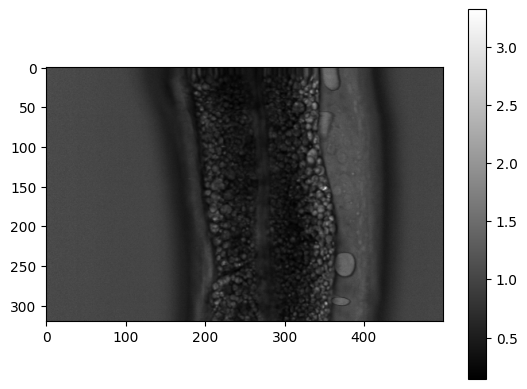

In [7]:
%matplotlib inline
plt.imshow(ratio[:,:,signature_index], cmap='gray')
plt.colorbar()

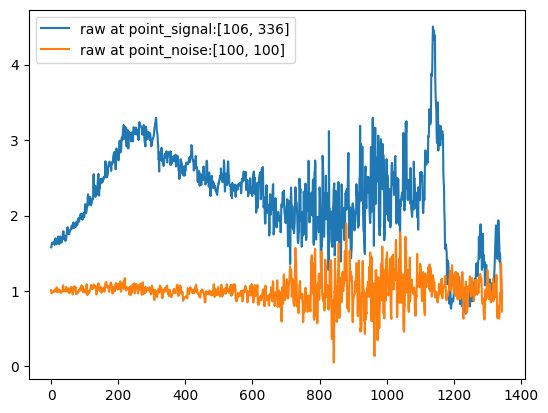

In [8]:

plt.plot(ratio_selected[point_signal[0],point_signal[1],:],label=f'raw at point_signal:{point_signal}')
plt.plot(ratio_selected[point_noise[0],point_noise[1],:],label=f'raw at point_noise:{point_noise}')
plt.legend()

In [9]:
svd_decompose = SVDDecompose()
# Load the HDF5 dataset into a NumPy array
U,s,Vh = svd_decompose.calculate(ratio_selected)

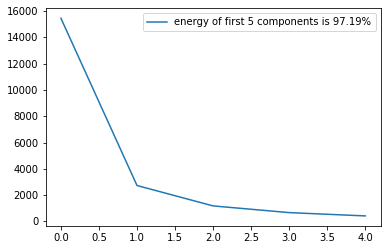

In [10]:
%matplotlib widget
svs = np.arange(5)  # Select singular values 0 to 10
plt.plot(s[svs],label='energy of first {} components is {:.2f}'.format(len(svs),np.sum(s[svs]**2)/np.sum(s**2)*100)+'%')
plt.legend()


In [11]:

# Only keep selected singular values and corresponding vectors
U_sel = U[:, svs]
s_sel = s[svs]
Vh_sel = Vh[svs, :]

# Multiply each row of Vh_sel by the corresponding singular value
reconstructed = np.dot(U_sel, s_sel[:, None] * Vh_sel)
reconstructed_reshaped = reconstructed.reshape(ratio_selected.shape)

(400.0, 3400.0)

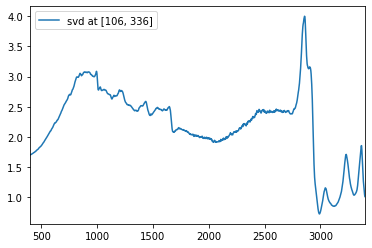

In [21]:
%matplotlib inline
#plt.plot(wn_selected,ratio_selected[point_signal[0],point_signal[1],:], label=f'raw at {point_signal}')
plt.plot(wn_selected, reconstructed_reshaped[point_signal[0],point_signal[1],:],label =f'svd at {point_signal}')
##plt.plot(wn_selected,ratio_selected[point_noise[0],point_noise[1],:], label=f'raw at {point_noise}')
#plt.plot(wn_selected, reconstructed_reshaped[point_noise[0],point_noise[1],:],label =f'svd at {point_noise}')
plt.legend()
plt.savefig("svd.pdf",format='pdf', backend='pdf')  # Ensure vector PDF
plt.xlim([400,3400])
#plt.ylim([0.8,1.2])

In [12]:
kkrelation = KramersKronig(cars_amp_offset=0.0, nrb_amp_offset=0.0, conjugate=False,
                 phase_offset=0.0, norm_to_nrb=True, pad_factor=1, 
                 rng=None, n_edge=30, axis=-1, bad_value=1e-8, min_value=None)
bg = np.ones(ratio_selected.shape)
cri_denoised = reconstructed_reshaped
ph_denoised = kkrelation.calculate(cri_denoised,bg)

Text(0.5, 1.0, 'KK on SVD denoised data at pixel [106, 336]')

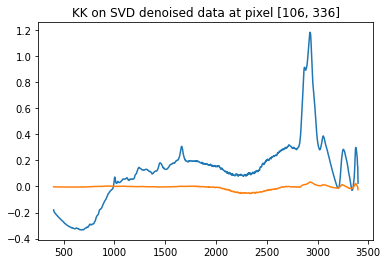

In [14]:
plt.plot(wn_selected,np.imag(ph_denoised[point_signal[0],point_signal[1],:]), label=f'denoised at signal{point_signal}')
plt.plot(wn_selected,np.imag(ph_denoised[point_noise[0],point_noise[1],:]), label=f'denoised at background{point_noise}')
plt.title('KK on SVD denoised data at pixel {}'.format(point_signal))

In [31]:
cri_raw = ratio_selected
ph_raw = kkrelation.calculate(cri_raw,bg)
plt.plot(wn_selected,np.imag(ph_raw[point_signal[0],point_signal[1],:]), label=f'raw at {point_signal}')
plt.plot(wn_selected,np.imag(ph_raw[point_noise[0],point_noise[1],:]), label=f'raw at {point_noise}')
plt.title(f'KK on raw data at pixel {point_signal}')

: 

In [15]:
pec = PhaseErrCorrectALS(smoothness_param=1, asym_param=5e-5,
                 redux=5, order=2, rng=None, fix_end_points=False,
                 fix_rng=None, fix_const=1, max_iter=100, min_diff=1e-6,
                 verbose=False)

In [16]:
ph_denoised_corrected = pec.calculate(ph_denoised)
#ph_raw_corrected = pec.calculate(ph_raw)


Text(0.5, 1.0, 'KK + Phase Error Correction on SVD denoised data at pixel [106, 336]')

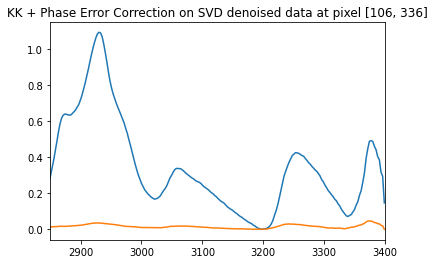

In [24]:
%matplotlib inline
plt.plot(wn_selected,np.imag(ph_denoised_corrected[point_signal[0],point_signal[1],:]), label=f'denoised at signal{point_signal}')
plt.plot(wn_selected,np.imag(ph_denoised_corrected[point_noise[0],point_noise[1],:]), label=f'denoised at background{point_noise}')
plt.xlim([2850,3400])
#plt.ylim([-0.05,0.15])
plt.savefig("kk_pec_CH.pdf",format='pdf', backend='pdf')  # Ensure vector PDF
plt.title(f'KK + Phase Error Correction on SVD denoised data at pixel {point_signal}')

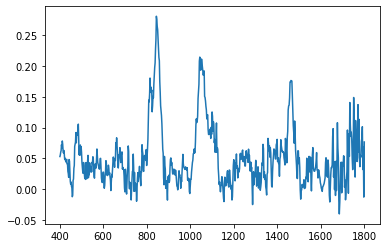

In [ ]:
ph_raw_corrected = pec.calculate(ph_raw)
#ph_raw_corrected = pec.calculate(ph_raw)


Text(0.5, 1.0, 'KK + Phase Error Correction on raw data at pixel 100,100')

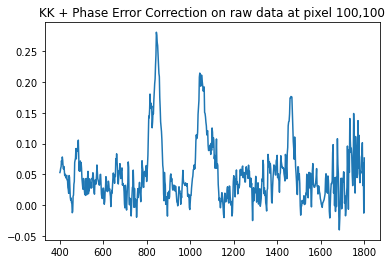

In [35]:
plt.plot(wn_selected,np.imag(ph_raw_corrected[100,100,:]))
plt.title('KK + Phase Error Correction on raw data at pixel 100,100')

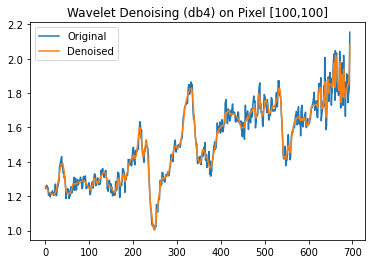

In [24]:
import pywt
import numpy as np

# Example: Denoise a single pixel spectrum
def wavelet_denoise_spectrum(spectrum, wavelet='db4', level=3, threshold_factor=1.2):
    coeffs = pywt.wavedec(spectrum, wavelet, level=level)
    # Universal threshold (can be tuned)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = threshold_factor * sigma * np.sqrt(2 * np.log(len(spectrum)))
    coeffs_thresh = [pywt.threshold(c, value=uthresh, mode='soft') if i > 0 else c for i, c in enumerate(coeffs)]
    return pywt.waverec(coeffs_thresh, wavelet)[:len(spectrum)]

# Apply to the whole cube (along spectral axis)
cri_wl = np.empty_like(ratio_selected)
for i in range(ratio_selected.shape[0]):
    for j in range(ratio_selected.shape[1]):
        cri_wl[i, j, :] = wavelet_denoise_spectrum(ratio_selected[i, j, :])
# Example: plot before and after for a pixel
plt.plot(ratio_selected[100, 100, :], label='Original')
plt.plot(cri_wl[100, 100, :], label='Denoised')
plt.legend()
plt.title('Wavelet Denoising (db4) on Pixel [100,100]')
plt.show()

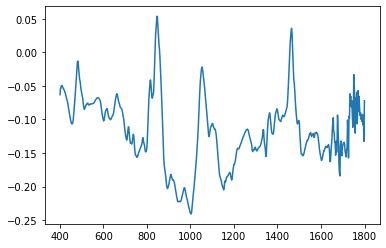

In [25]:
cri_wl_ph = kkrelation.calculate(cri_wl,bg)
plt.plot(wn_selected,np.imag(cri_wl_ph[100,100,:]))

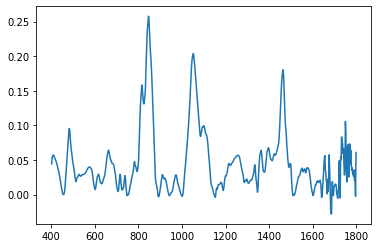

In [26]:
cri_wl_ph_corrected = pec.calculate(cri_wl_ph)
#ph_raw_corrected = pec.calculate(ph_raw)
plt.plot(wn_selected,np.imag(cri_wl_ph_corrected[100,100,:]))

wn
